
## DATA 301 Final Project - Which predictors are the most related to a country’s happiness outside of the normal factors?  

In [ ]:
import pandas as pd
train_set = pd.read_csv("/content/train_set.csv")

**The Top 5 happiest countries around the world are Finland, Denmark, Norway, Iceland, and Netherlands**

In [ ]:
sorted_train_set = train_set.sort_values(by="Score", ascending=False)
sorted_train_set.head(5)

,Unnamed: 0,Score,name,unemployment,homicide_rate,forested_area,internet_users,pop_density,co2_emissions,Secondary Enrollment Average,Life Expectancy Average
0,0,7.769,Finland,6.7,1.6,73.1,88.9,18.2,42.6,154.15,81.65
1,1,7.600,Denmark,4.8,1.0,15.3,97.3,136.5,31.3,129.10,80.70
2,2,7.554,Norway,3.3,0.5,33.2,96.5,14.8,34.8,116.80,82.20
3,3,7.494,Iceland,3.2,0.9,0.5,99.0,3.4,2.2,117.50,82.75
4,4,7.488,Netherlands,3.0,0.6,11.2,94.7,508.2,155.6,135.60,82.05


**The 5 least happiness countires in the world are South Sudan, Central African Republic, Afghanistan, Rwanda, and Yemen.**


In [ ]:
sorted_train_set = train_set.sort_values(by="Score", ascending=True)
sorted_train_set.head(5)

,Score,name,unemployment,homicide_rate,forested_area,internet_users,pop_density,co2_emissions,Secondary Enrollment Average,Life Expectancy Average
146,2.853,South Sudan,12.3,14.9,NaN,8.0,18.3,1.5,11.00,57.45
145,3.083,Central African Republic,3.7,20.1,35.6,4.3,7.8,NaN,17.15,52.70
144,3.203,Afghanistan,11.2,6.7,2.1,13.5,59.6,NaN,55.05,64.30
142,3.334,Rwanda,1.0,2.6,19.5,21.8,525.0,NaN,40.90,68.40
141,3.380,Yemen,12.8,6.8,1.0,26.7,56.5,8.9,51.45,66.05


Here is a for loop that shows each variable and its mean, standard deviation, min, and other descriptive variables

In [ ]:
Features = ["Score", "unemployment", "homicide_rate", "forested_area",
            "internet_users", "pop_density", "co2_emissions", "Secondary Enrollment Average", "Life Expectancy Average"]

for feature in Features:
  print(feature,
      train_set[feature].describe())

Score count    136.000000
mean       5.461610
std        1.137584
min        2.853000
25%        4.530250
50%        5.431000
75%        6.230500
max        7.769000
Name: Score, dtype: float64
unemployment count    136.000000
mean       6.839706
std        4.984826
min        0.100000
25%        3.575000
50%        5.200000
75%        9.025000
max       28.500000
Name: unemployment, dtype: float64
homicide_rate count    125.00000
mean       6.20080
std       10.08475
min        0.20000
25%        1.10000
50%        2.20000
75%        6.20000
max       52.00000
Name: homicide_rate, dtype: float64
forested_area count    134.000000
mean      26.538806
std       20.086995
min        0.000000
25%        9.075000
50%       25.650000
75%       38.675000
max       89.300000
Name: forested_area, dtype: float64
internet_users count    136.000000
mean      56.756618
std       29.078368
min        2.000000
25%       30.275000
50%       64.150000
75%       80.825000
max       99.700000
Name: inter

This set of graphs plots each feature against the Happiness Score. Based on looking at the graphs, internet users, secondary enrolllment average, and life expectancy average showed the best positive coorelation.

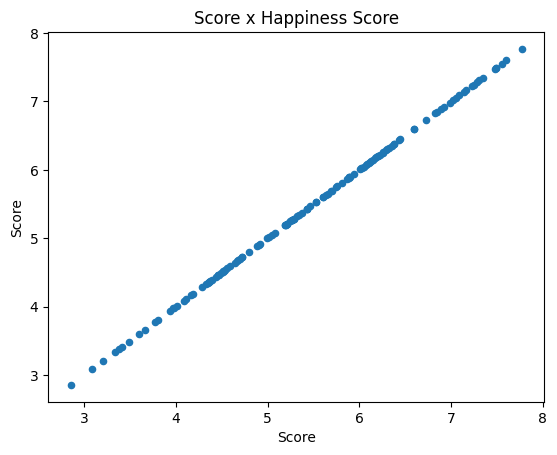

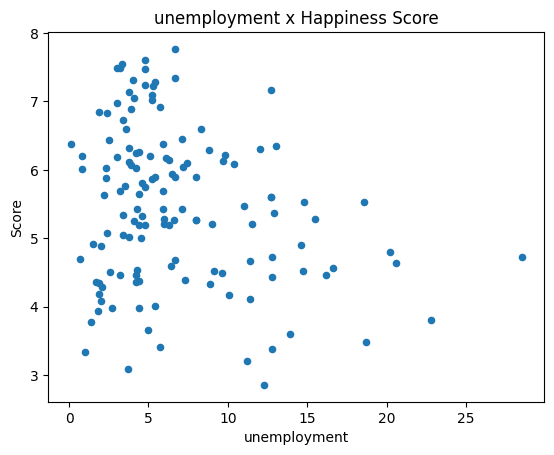

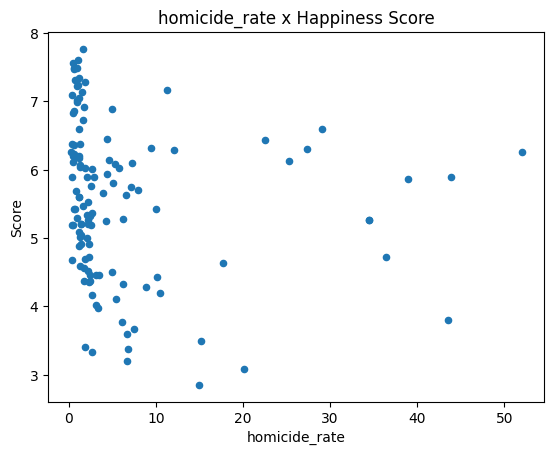

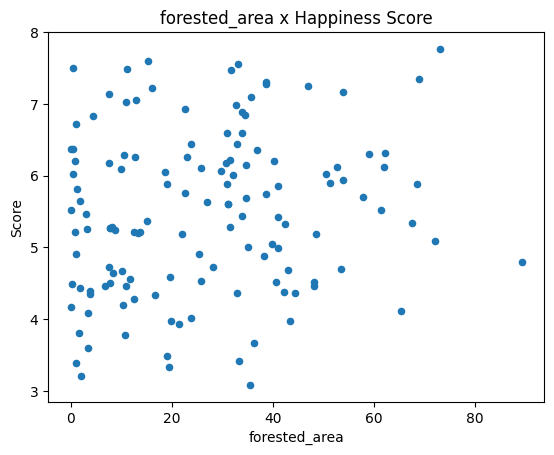

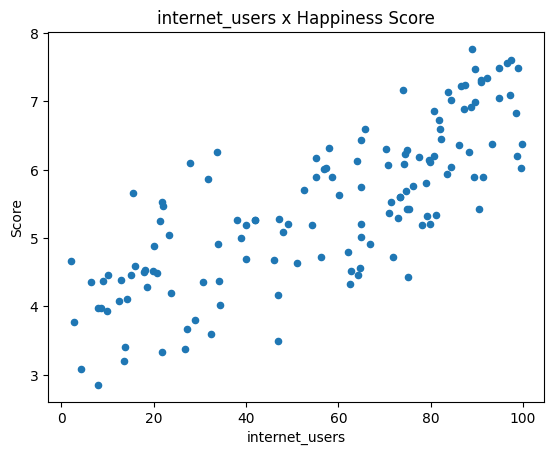

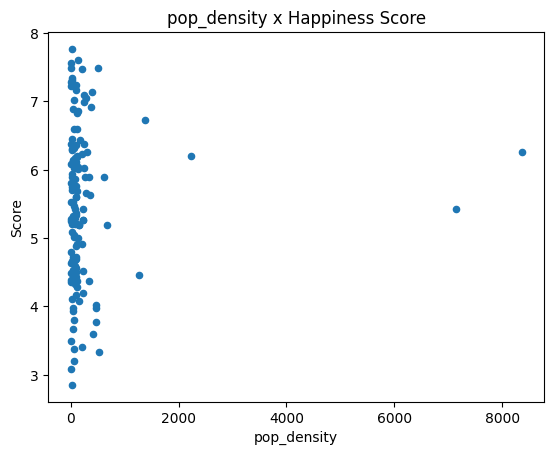

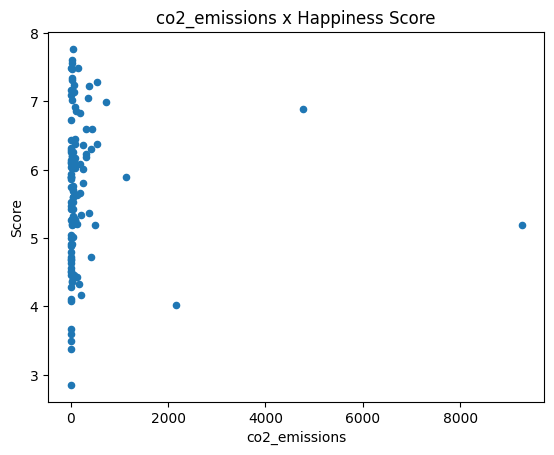

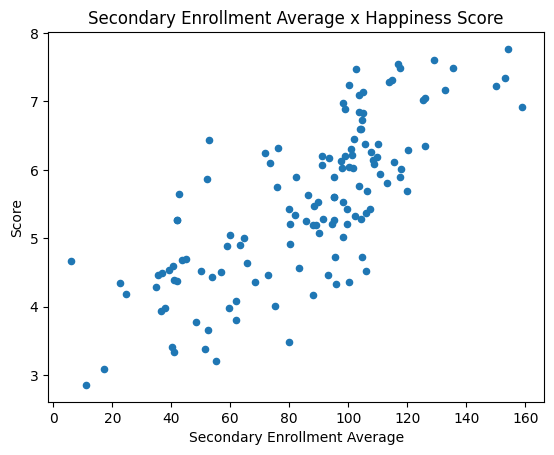

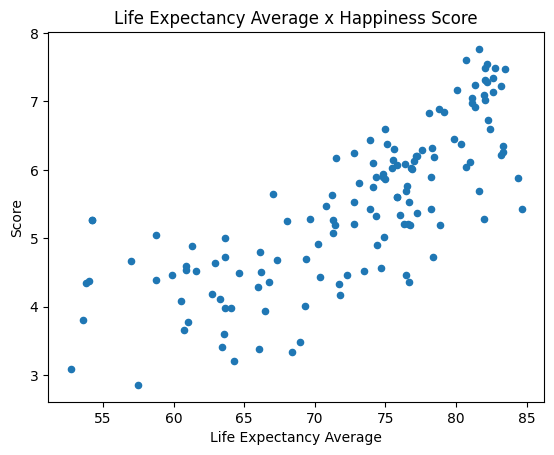

In [ ]:
for feature in Features:
  train_set.plot.scatter(x = feature, y = "Score",
                       title = f"{feature} x Happiness Score")

In [ ]:
for feature in Features:
  print(feature,
      train_set["Score"].corr(train_set[feature]))

Life Expectancy Average 0.7731302655199972
unemployment -0.24324870657380987
homicide_rate -0.13659439941225318
forested_area 0.1597184549158081
internet_users 0.7870562235036334
pop_density 0.05524850367061207
co2_emissions 0.017816686410963026
Secondary Enrollment Average 0.7590517300196802
Life Expectancy Average 0.7731302655199972


On the scatter plots of all the features of every country, we see that **Life Expecatnacy, internet users, Secondary Enrollment Average** have a strong correlation to Happiness Score. However, there are some negative correlations and outliers within the distribution of the data.




Under here we will look into the data and see which countries are outliers within the data set.

In [ ]:
def outliers(data):
  Q1 = data.quantile(0.25)
  Q3 = data.quantile(0.75)
  IQR = Q3 - Q1
  bound = IQR * 1.5
  lower =  Q1 - bound
  upper = Q3 + bound
  outliers = data[(data < lower) | (data > upper)]
  return outliers

**Under here we see that unemployment has six Outliers in their data set:**


*   Libya
*   Gabon
*   South Africa
*   Namibia
*   Lesotho
*   Botswana





In [ ]:
Unemploy_rate_outlier = outliers(train_set["unemployment"])
Uoutliers_df = train_set[train_set["unemployment"].isin(Unemploy_rate_outlier)]
Uoutliers_df

,Score,name,unemployment,homicide_rate,forested_area,internet_users,pop_density,co2_emissions,Secondary Enrollment Average,Life Expectancy Average
68,5.525,Libya,18.6,NaN,0.1,21.8,3.9,41.5,98.10,72.80
98,4.799,Gabon,20.2,NaN,89.3,62.0,8.6,3.4,NaN,66.10
99,4.722,South Africa,28.5,36.4,7.6,56.2,48.9,421.7,104.70,63.65
105,4.639,Namibia,20.6,17.7,8.4,51.0,3.1,4.0,65.75,62.90
134,3.802,Lesotho,22.8,43.6,1.6,29.0,70.6,NaN,62.05,53.60
138,3.488,Botswana,18.7,15.2,19.1,47.0,4.1,7.7,79.95,68.95


**Under here we see that homicide_rate has 15 Outliers in their data set:**

In [ ]:
Homiced_rate_outlier = outliers(train_set["homicide_rate"])
Houtliers_df = train_set[train_set["homicide_rate"].isin(Homiced_rate_outlier)]
Houtliers_df

,Score,name,unemployment,homicide_rate,forested_area,internet_users,pop_density,co2_emissions,Secondary Enrollment Average,Life Expectancy Average
22,6.595,Mexico,3.6,29.1,34.0,65.8,66.3,446.0,104.45,74.95
25,6.436,Guatemala,2.5,22.5,33.0,65.0,167.2,15.7,52.70,73.90
30,6.300,Brazil,12.0,27.4,59.0,70.4,25.4,427.6,100.85,75.60
33,6.253,El Salvador,4.2,52.0,12.8,33.8,313.0,5.7,71.65,72.80
41,6.125,Colombia,9.7,25.3,52.7,64.1,45.9,75.3,97.55,77.00
53,5.890,Jamaica,8.0,43.9,31.0,55.1,273.4,7.0,82.30,74.35
56,5.860,Honduras,5.2,38.9,41.0,31.7,88.5,9.4,52.25,75.00
81,5.265,Nigeria,8.0,34.5,7.7,42.0,226.3,86.0,41.95,54.20
99,4.722,South Africa,28.5,36.4,7.6,56.2,48.9,421.7,104.70,63.65
105,4.639,Namibia,20.6,17.7,8.4,51.0,3.1,4.0,65.75,62.90


**Under here we see that forested areas has 1 Outliers in their data set:**

In [ ]:
Forrest_outlier = outliers(train_set["forested_area"])
Forrest_df = train_set[train_set["forested_area"].isin(Forrest_outlier)]
Forrest_df

,Score,name,unemployment,homicide_rate,forested_area,internet_users,pop_density,co2_emissions,Secondary Enrollment Average,Life Expectancy Average
98,4.799,Gabon,20.2,NaN,89.3,62.0,8.6,3.4,NaN,66.1


**Under here we see that internet_users has no outliers**

In [ ]:
Internet_Outlier = outliers(train_set["internet_users"])
Internet_df = train_set[train_set["internet_users"].isin(Internet_Outlier)]
Internet_df

,Score,name,unemployment,homicide_rate,forested_area,internet_users,pop_density,co2_emissions,Secondary Enrollment Average,Life Expectancy Average


**Under here we see that pop_density has no outliers**

In [ ]:
Pop_Outlier = outliers(train_set["pop_density"])
Pop_df = train_set[train_set["pop_density"].isin(Pop_Outlier)]
Pop_df

,Score,name,unemployment,homicide_rate,forested_area,internet_users,pop_density,co2_emissions,Secondary Enrollment Average,Life Expectancy Average
4,7.488,Netherlands,3.0,0.6,11.2,94.7,508.2,155.6,135.60,82.05
21,6.726,Malta,3.4,1.6,1.1,81.7,1379.8,1.5,104.75,82.25
32,6.262,Singapore,4.4,0.2,23.1,88.2,8357.6,47.4,107.55,83.35
35,6.199,Bahrain,0.8,0.5,0.8,98.6,2238.9,29.8,98.75,77.20
54,5.888,Mauritius,6.7,2.9,19.0,58.6,626.5,4.2,95.15,74.80
72,5.430,Hong Kong,4.3,0.7,NaN,90.5,7140.0,44.0,107.45,84.65
87,5.197,Lebanon,6.3,2.5,13.4,78.2,667.2,26.9,NaN,78.90
117,4.456,Bangladesh,4.2,2.4,11.0,15.0,1265.2,78.3,72.85,72.30
130,4.015,India,5.4,3.1,23.8,34.4,464.1,2161.6,75.25,69.30
132,3.973,Comoros,4.4,NaN,19.9,8.5,467.3,NaN,59.50,64.05


**Under here we see that homicide_rate has 15 Outliers in their data set:**

In [ ]:
Co2_Outlier = outliers(train_set["co2_emissions"])
Co2_df = train_set[train_set["co2_emissions"].isin(Co2_Outlier)]
Co2_df

,Score,name,unemployment,homicide_rate,forested_area,internet_users,pop_density,co2_emissions,Secondary Enrollment Average,Life Expectancy Average
8,7.278,Canada,5.4,1.8,38.7,91.0,4.2,547.8,113.75,82.20
10,7.228,Australia,5.3,0.9,16.2,86.5,3.3,384.6,150.10,83.20
14,7.054,United Kingdom,4.1,1.2,13.0,94.9,280.6,358.7,125.90,81.15
16,6.985,Germany,3.0,0.9,32.7,89.7,240.4,718.8,98.30,81.15
18,6.892,United States,3.9,5.0,33.9,87.3,36.2,4761.3,98.95,78.80
22,6.595,Mexico,3.6,29.1,34.0,65.8,66.3,446.0,104.45,74.95
23,6.592,France,8.3,1.2,31.0,82.0,119.2,306.1,103.80,82.40
26,6.375,Saudi Arabia,5.9,1.3,0.5,93.3,16.2,532.2,110.00,75.10
30,6.300,Brazil,12.0,27.4,59.0,70.4,25.4,427.6,100.85,75.60
34,6.223,Italy,9.8,0.6,31.6,74.4,205.6,321.5,101.25,83.20


**There are no outliers within the Secondary Enrollment Average**

In [ ]:
Second_Outlier = outliers(train_set["Secondary Enrollment Average"])
Second_df = train_set[train_set["Secondary Enrollment Average"].isin(Second_Outlier)]
Second_df

,Score,name,unemployment,homicide_rate,forested_area,internet_users,pop_density,co2_emissions,Secondary Enrollment Average,Life Expectancy Average


**There are no outliers within the Life Expectancy Average**

In [ ]:
Life_Outlier = outliers(train_set["Life Expectancy Average"])
Life_df = train_set[train_set["Life Expectancy Average"].isin(Life_Outlier)]
Life_df

,Score,name,unemployment,homicide_rate,forested_area,internet_users,pop_density,co2_emissions,Secondary Enrollment Average,Life Expectancy Average
